In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'

In [86]:
er = xr.open_zarr(data_dir + 'stacks/east_river')
er_filt = xr.open_zarr(data_dir + 'stacks/east_river_filtered')

In [87]:
aso = xr.open_dataarray(data_dir + 'ASO_EastRiver_2026Mar18_swe_50m.tif')
er = er.where(aso.rio.reproject_match(er.rio.write_crs('EPSG:4326')).notnull()).squeeze()
er_filt = er_filt.where(aso.rio.reproject_match(er_filt.rio.write_crs('EPSG:4326')).notnull()).squeeze()

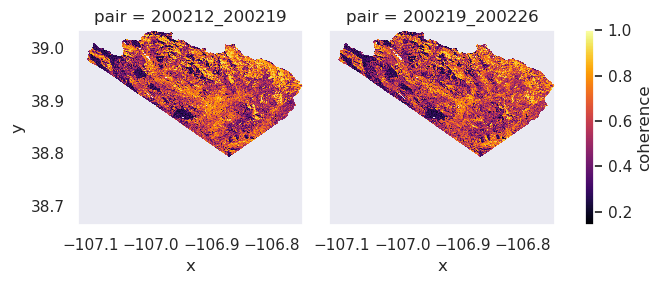

In [73]:
er.sel(pol='VV')['coherence'].plot(col='pair', cmap='inferno')

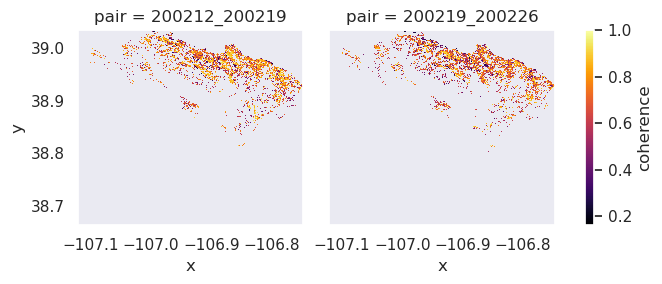

In [88]:
er_filt.sel(pol='VV')['coherence'].plot(col='pair', cmap='inferno')

In [74]:
date_pairs = [s.split("_") for s in er['pair'].values]
date_pairs = [pd.to_datetime(s, format='%y%m%d').tz_localize('US/Mountain') for s in date_pairs]
print(date_pairs)
unique_dates = np.unique(date_pairs)
unique_dates

[DatetimeIndex(['2020-02-12 00:00:00-07:00', '2020-02-19 00:00:00-07:00'], dtype='datetime64[us, US/Mountain]', freq=None), DatetimeIndex(['2020-02-19 00:00:00-07:00', '2020-02-26 00:00:00-07:00'], dtype='datetime64[us, US/Mountain]', freq=None)]


array([Timestamp('2020-02-12 00:00:00-0700', tz='US/Mountain'),
       Timestamp('2020-02-19 00:00:00-0700', tz='US/Mountain'),
       Timestamp('2020-02-26 00:00:00-0700', tz='US/Mountain')],
      dtype=object)

In [62]:
snotel_2020 = pd.read_csv(data_dir + 'stations/snotel/schofield_pass_snotel_2020.csv', header=10)
snotel_2020 = snotel_2020.drop(snotel_2020.index[0]) # units row 
# print(snotel_2020.columns)

# set types 
snotel_2020['datetime'] = pd.to_datetime(snotel_2020['Date_Time'], utc=True).dt.tz_convert('US/Mountain')
snotel_2020 = snotel_2020.set_index('datetime')
snotel_2020['swe_mm'] = snotel_2020['snow_water_equiv_set_1'].astype(float)
snotel_2020['wind_mps'] = snotel_2020['wind_speed_set_1'].astype(float)

# select rows i need 
snotel_2020 = snotel_2020[['swe_mm', 'wind_mps', 'air_temp_set_1']]
snotel_2020['swe_diff_mm'] = np.insert(np.diff(snotel_2020['swe_mm']), 0, 0)
snotel_2020 = snotel_2020.loc['2020-02-01':'2020-02-28']
snotel_2020

,swe_mm,wind_mps,air_temp_set_1,swe_diff_mm
datetime,,,,
2020-02-01 00:00:00-07:00,431.80,0.13,-8.1,0.00
2020-02-01 01:00:00-07:00,434.34,0.72,-5.9,2.54
2020-02-01 02:00:00-07:00,434.34,0.63,-6.1,0.00
2020-02-01 03:00:00-07:00,434.34,0.36,-6.8,0.00
2020-02-01 04:00:00-07:00,431.80,0.18,-7.7,-2.54
...,...,...,...,...
2020-02-28 19:00:00-07:00,576.58,0.27,-2.9,-2.54
2020-02-28 20:00:00-07:00,579.12,0.09,-5.5,2.54
2020-02-28 21:00:00-07:00,581.66,0.09,-6.4,2.54


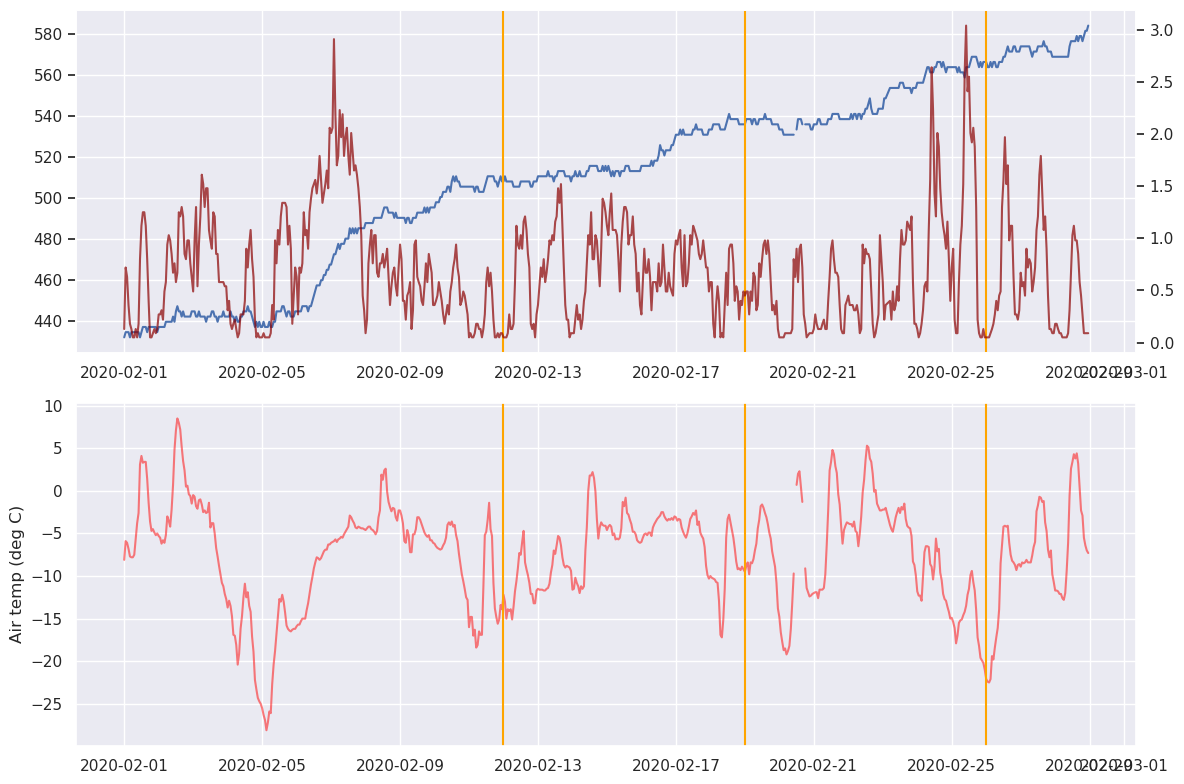

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
(ax, ax3) = axes
ax2 = ax.twinx()

ax.plot(snotel_2020['swe_mm'].astype(float))
ax2.plot(snotel_2020['wind_mps'].astype(float), c='darkred', alpha=0.7)
ax2.grid(False)
ax3.plot(snotel_2020['air_temp_set_1'].astype(float), c='red', alpha=0.5)
ax3.set_ylabel('Air temp (deg C)')

[ax.axvline(d, c='orange') for d in unique_dates]
[ax3.axvline(d, c='orange') for d in unique_dates]

plt.tight_layout()
plt.show()

In [89]:
snotel_6h = snotel_2020.resample('6h').agg({
    'swe_diff_mm': 'sum',
    'wind_mps': 'mean'
})

In [90]:
threshold = 5  # mm, set to whatever makes sense for your data

def event_window_wind_avg(df, threshold, freq='6h'):
    """
    For a single period's dataframe, find all timestamps where swe_diff_mm 
    exceeds threshold, then flag those timestamps plus the following 24h.
    Return mean wind_mps over the union of all flagged windows.
    """
    events = df.index[df['swe_diff_mm'] > threshold]
    
    if len(events) == 0:
        return np.nan  # or 0, or skip — depends what you want for no-event periods
    
    # build a boolean mask covering each event timestamp + 24h after
    mask = pd.Series(False, index=df.index)
    for t in events:
        window_end = t + pd.Timedelta(hours=24)
        mask |= (df.index >= t) & (df.index <= window_end)
    
    return df.loc[mask, 'wind_mps'].mean()

def merge_windows(windows):
    windows = sorted(windows)
    merged = []
    for start, end in windows:
        if merged and start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))
    return merged

def get_event_windows(df, threshold, start, end, hours_after=24):
    events = df.index[df['swe_diff_mm'] > threshold]
    windows = [(t, min(t + pd.Timedelta(hours=hours_after), end)) for t in events]
    return windows

avg_winds = []
for start, end in date_pairs:
    period_df = snotel_6h.loc[start:end]
    windows = merge_windows(get_event_windows(period_df, threshold, start, end))
    mask = pd.Series(False, index=period_df.index)
    for w_start, w_end in windows:
        mask |= (period_df.index >= w_start) & (period_df.index <= w_end)
    avg_winds.append(period_df.loc[mask, 'wind_mps'].mean())

results_df = pd.DataFrame(avg_winds)
print(results_df)

          0
0  0.752143
1  0.762778


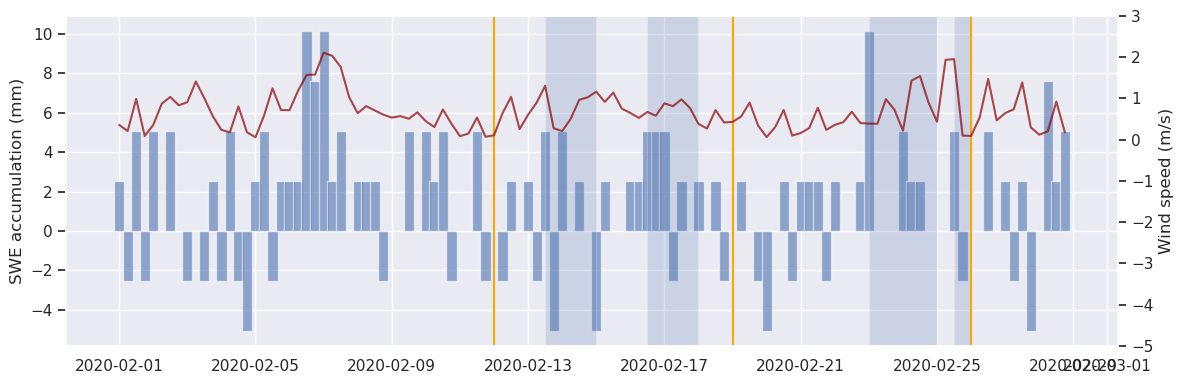

In [91]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

ax.bar(snotel_6h.index, snotel_6h['swe_diff_mm'], edgecolor=None, alpha=0.6, width=0.3)
ax.set_ylabel('SWE accumulation (mm)')

ax2.plot(snotel_6h['wind_mps'], c='darkred', alpha=0.7)
ax2.set_ylabel('Wind speed (m/s)')
ax2.set_ylim((-5, 3))
ax2.grid(False)

[ax.axvline(d, c='orange') for d in unique_dates]
for start, end in date_pairs:
    period_df = snotel_6h.loc[start:end]
    windows = merge_windows(get_event_windows(period_df, threshold, start, end))
    for w_start, w_end in windows:
        ax.axvspan(w_start, w_end, alpha=0.2)

plt.tight_layout()
plt.show()

In [92]:
print('filtered pixels')
print('   pair 1   pair 2')
print(er_filt.mean(dim=['x', 'y']).sel(pol='VV')['coherence'].values)
print('unfiltered pixels')
print('   pair 1   pair 2')
print(er.mean(dim=['x', 'y']).sel(pol='VV')['coherence'].values)

filtered pixels
   pair 1   pair 2
[0.6996877  0.67614555]
unfiltered pixels
   pair 1   pair 2
[0.58234113 0.56756294]


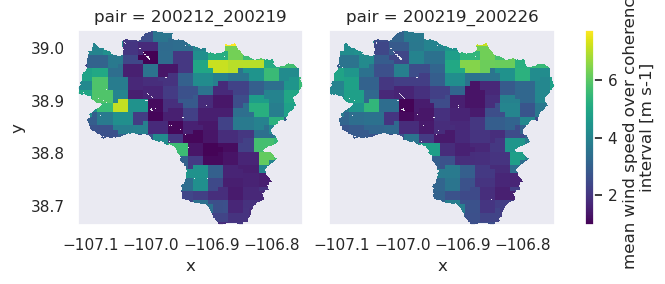

In [98]:
er['mean_wind'].plot(col='pair')

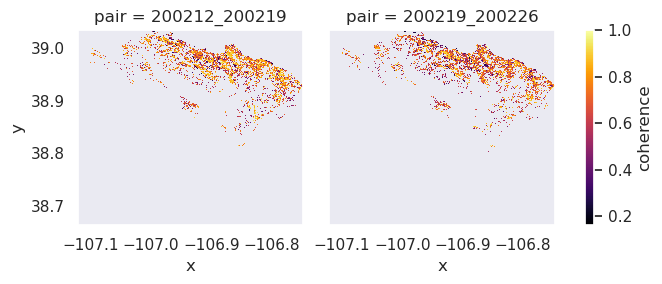

In [94]:
er_filt.sel(pol='VV')['coherence'].plot(col='pair', cmap='inferno')

In [95]:
er_filt['coherence'].values

array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],


       [[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., 

In [96]:
er_filt['pair'].values

array(['200212_200219', '200219_200226'], dtype='<U13')

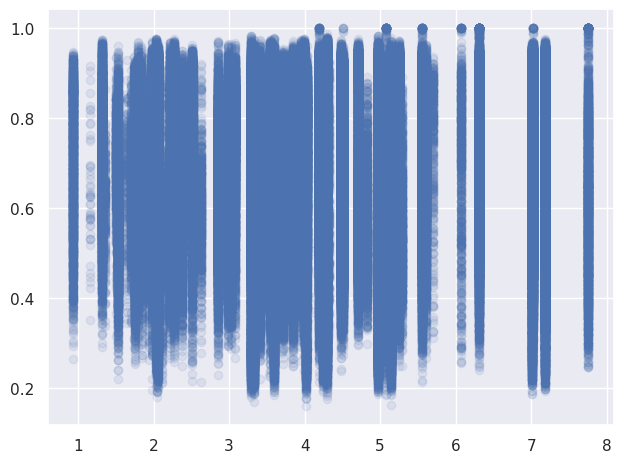

In [97]:
fig, ax = plt.subplots()

ax.scatter(er_filt.sel(pair='200212_200219')['mean_wind'].values.squeeze(), 
    er_filt.sel(pol='VV', pair='200212_200219')['coherence'].values.squeeze(), alpha=0.1)

plt.tight_layout()
plt.show()